In [45]:
# Exploratory Analysis (scratch / not final)
#Early exploration in Python. Population is averaged per country (a yearly stock, not summed); disaster totals are summed as cumulative flows. Main challenge: aligning World Bank population to the correct country-year grain — straightforward to explore here, harder to model as a per-year mart join. The finalised logic lives in the BigQuery `int_populationdf1` view and the marts.

In [46]:
from google.cloud import bigquery
import pandas_gbq as pd_gbq

In [47]:
!pip install kaleido==0.2.1
import plotly.io as pio

In [48]:
query = '''
SELECT
  year,
  SUM(refugees) AS total_refugees
FROM `ontherun-499508.int.int_refugees_total_clean`
GROUP BY year
ORDER BY year
'''
df_refugees_tot = pd_gbq.read_gbq(query, project_id="ontherun-499508")

Downloading: 100%|██████████|


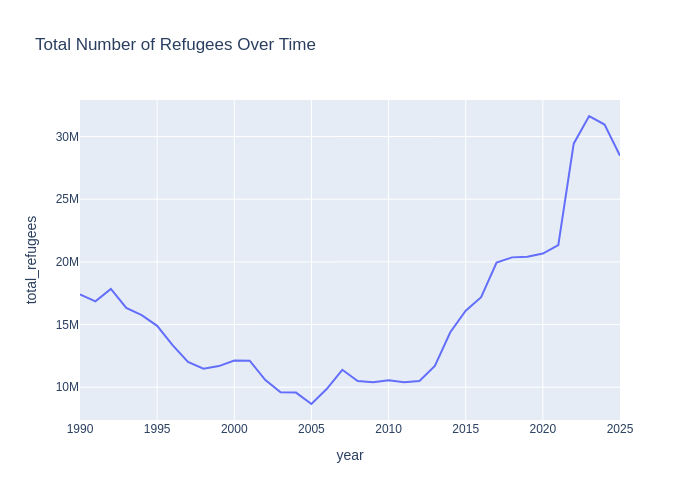

In [89]:
import plotly.express as px

fig = px.line(
    df_refugees_tot,
    x="year",
    y="total_refugees",
    title="Total Number of Refugees Over Time"
)

fig.show()

In [50]:
## query above we trying to explore how the number of total refugee/ increases or decreases by year 1990-2025

Below I am trying to answer: -disaster aspect - IDPs then refugees- Scope: Over the years, the biggest disaster => country that is impacted by the

- biggest disaster the most
=> country has the highest disaster level impact != not necessarily from the biggest disaster but the accumulation of nb of disasters
=> find out nb of ppl leaving/displace => which country produces more; look at single countries
=> then maybe could start where they go to

H1: Over the years, which country has had the highest number of IDPs because of disaster -- which country has had the highest number of refugees.



How do we define - -biggest disaster ? = the disaster that affected the most people.
1. Biggest year globally (which year was the worst overall)
= 2002, biggest impact globally with 659385138-global disaster total affected.
2. Country with highest cumulative impact (which country bears the heaviest disaster burden across all years)
3. Displacement: for those years and countries, what happened to IDPs and refugees

In [52]:
from google.cloud import bigquery
import pandas_gbq as pd_gbq

query = '''
SELECT
  year,
  SUM(disaster_total_affected) AS cumulative_disaster_impact
FROM `ontherun-499508.mart.mart_disaster_analysis`
GROUP BY year
ORDER BY cumulative_disaster_impact
'''
df_dis = pd_gbq.read_gbq(query, project_id="ontherun-499508")

Downloading: 100%|██████████|


In [53]:
df_dis.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 2 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   year                        36 non-null     Int64
 1   cumulative_disaster_impact  36 non-null     Int64
dtypes: Int64(2)
memory usage: 780.0 bytes


In [54]:
df_dis.head()

,year,cumulative_disaster_impact
0,1992,60811665
1,1997,70299154
2,1990,73215941
3,2018,84116816
4,2013,99390074


In [55]:
## above we have identified throughout 1990-2026, 36 years - 2002 has the highest number of disaster impact, globally across the globe.
## year and sum disaster affected we are just suming the disaster affected number from each country so meaning if 2002 appear the highest- meaning across the globe - 2002 has the highest , number througout the year from all country highest number of affected.

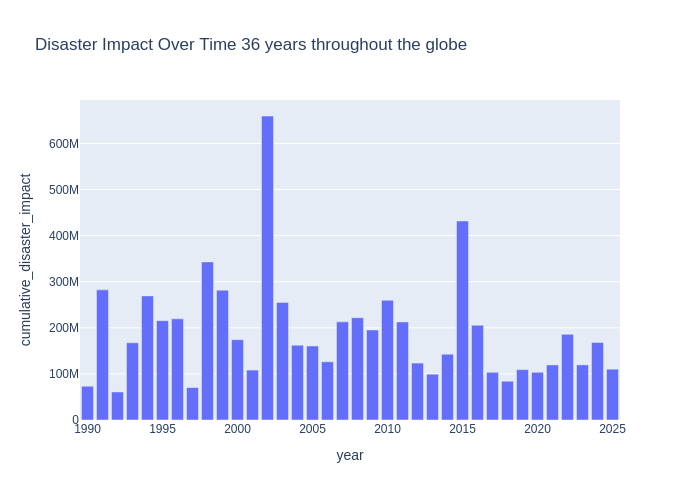

In [56]:
import plotly.express as px

fig = px.bar(
    df_dis,
    x="year",
    y="cumulative_disaster_impact",
    title="Disaster Impact Over Time 36 years throughout the globe"
)

fig.show()

In [57]:
## below we have identify bar graph - we could further narrowed it down to top 10 years out of 36 years

In [58]:
## below we started to query - Grouping by country, looking for the cumulative impact across all years

In [59]:
query = '''
SELECT
  country_of_origin,
  COUNT(year) AS nb_years,
  SUM(disaster_total_affected) AS cumulative_disaster_impact
FROM `ontherun-499508.mart.mart_disaster_analysis`
GROUP BY country_of_origin
ORDER BY cumulative_disaster_impact DESC
'''
df_dis = pd_gbq.read_gbq(query, project_id="ontherun-499508")

Downloading: 100%|██████████|


In [60]:
df_dis.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 215 entries, 0 to 214
Data columns (total 3 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   country_of_origin           215 non-null    object
 1   nb_years                    215 non-null    Int64 
 2   cumulative_disaster_impact  188 non-null    Int64 
dtypes: Int64(2), object(1)
memory usage: 5.6+ KB


In [61]:
df_dis.head(10)

,country_of_origin,nb_years,cumulative_disaster_impact
0,China,36,3023121029
1,India,36,1461976300
2,Philippines,36,286040810
3,Bangladesh,36,265592321
4,Pakistan,36,124071815
5,United States of America,35,114480297
6,Thailand,36,109789549
7,Ethiopia,36,87456509
8,Kenya,36,74601515
9,Brazil,36,69552706


In [62]:
df_dis[df_dis['cumulative_disaster_impact'].isnull()]

,country_of_origin,nb_years,cumulative_disaster_impact
188,Aruba,3,<NA>
189,Western Sahara,36,<NA>
190,Turkmenistan,32,<NA>
191,Andorra,23,<NA>
192,Bahrain,36,<NA>
193,Brunei Darussalam,12,<NA>
194,New Caledonia,2,<NA>
195,Malta,29,<NA>
196,Nauru,11,<NA>
197,Tuvalu,15,<NA>


In [63]:
query = '''
SELECT
  country_of_origin,
  COUNT(year) AS nb_years,
  SUM(disaster_total_affected) AS cumulative_disaster_impact,
  COUNTIF(disaster_total_affected IS NOT NULL) AS years_with_disaster_data
FROM `ontherun-499508.mart.mart_disaster_analysis`
GROUP BY country_of_origin
HAVING cumulative_disaster_impact IS NULL
'''
## HAVING use here to just check if the null from the mart dis_analysis data
df_dis_c = pd_gbq.read_gbq(query, project_id="ontherun-499508")

Downloading: 100%|██████████|


In [64]:
df_dis_c.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 4 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   country_of_origin           27 non-null     object
 1   nb_years                    27 non-null     Int64 
 2   cumulative_disaster_impact  0 non-null      Int64 
 3   years_with_disaster_data    27 non-null     Int64 
dtypes: Int64(3), object(1)
memory usage: 1.1+ KB


In [65]:
df_dis_c.head(3)

,country_of_origin,nb_years,cumulative_disaster_impact,years_with_disaster_data
0,Aruba,3,<NA>,0
1,Western Sahara,36,<NA>,0
2,Turkmenistan,32,<NA>,0


In [66]:
## 26 countries never once had a row from the disaster table join to them

In [67]:
query = '''
SELECT
  country_of_origin,
  COUNT(year) AS nb_years,
  SUM(disaster_total_affected) AS cumulative_disaster_impact
FROM `ontherun-499508.mart.mart_disaster_analysis`
GROUP BY country_of_origin
ORDER BY cumulative_disaster_impact DESC
'''

df_dis_c = pd_gbq.read_gbq(query, project_id="ontherun-499508")
df_dis_c = df_dis_c.dropna()

Downloading: 100%|██████████|


In [68]:
df_dis_c.tail(10)

,country_of_origin,nb_years,cumulative_disaster_impact
178,Kiribati,18,1805
179,Luxembourg,7,1519
180,Qatar,32,1500
181,United Arab Emirates,28,534
182,Saint Kitts and Nevis,24,500
183,Finland,26,400
184,Latvia,34,302
185,Denmark,32,243
186,"China, Macao SAR",25,205
187,Kuwait,36,200


In [69]:
## here we dropping columns ['global_affected']= null - we have checked. ; so proceed to plotting identify truth.

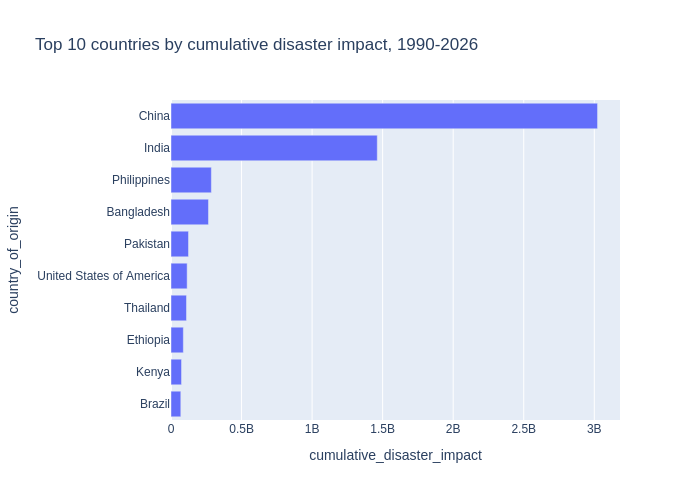

In [70]:
top10 = df_dis_c.head(10)

fig = px.bar(
    top10,
    x='cumulative_disaster_impact',
    y='country_of_origin',
    orientation='h',
    title='Top 10 countries by cumulative disaster impact, 1990-2026',
    hover_data=['nb_years']
)
fig.update_yaxes(categoryorder='total ascending')
fig.show()

In [71]:
##below we try to further investigate by:
##Dividing by population reveals which countries are proportionally hit hardest relative to their size, which is the fairer comparison.

In [72]:
query = '''
SELECT
  country_of_origin,
  COUNT(year) AS nb_years,
  SUM(disaster_total_affected) AS cumulative_disaster_impact,
  ROUND(AVG(population_total),2) AS avg_population,
  SAFE_DIVIDE(SUM(disaster_total_affected), AVG(population_total)) AS cumulative_affected_per_capita,
  AVG(SAFE_DIVIDE(disaster_total_affected, population_total)) AS avg_yearly_affected_share
FROM `ontherun-499508.mart.mart_disaster_analysis`
GROUP BY country_of_origin
ORDER BY cumulative_affected_per_capita DESC
'''

df_dis_country_pop_avg = pd_gbq.read_gbq(query, project_id="ontherun-499508")

Downloading: 100%|██████████|


In [73]:
import pandas as pd
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

In [74]:
df_dis_country_pop_avg.head(10)

,country_of_origin,nb_years,cumulative_disaster_impact,avg_population,cumulative_affected_per_capita,avg_yearly_affected_share
0,Somalia,36,44606296,"11,787,195.06",3.78,0.10
1,Philippines,36,286040810,"91,625,544.31",3.12,0.08
2,Cuba,36,33014217,"11,115,222.81",2.97,0.10
3,Malawi,36,43222785,"14,563,478.31",2.97,0.10
4,Mauritania,36,9341854,"3,351,895.78",2.79,0.11
5,Vanuatu,9,834620,"306,319.78",2.72,0.44
6,Zimbabwe,36,35175554,"13,190,618.19",2.67,0.10
7,Namibia,35,5472917,"2,133,544.71",2.57,0.10
8,China,36,3023121029,"1,310,104,444.00",2.31,0.07
9,Fiji,34,1936120,"879,637.94",2.20,0.11


In [75]:
#avg_yearly_affected_share - we answer :what share of this country's population gets hit by disaster
#cumulative_affected_per_capita - we answer :summed up across the whole period, what proportion of this country's people (sized at their average population) were affected overall
# from the compute above we are now able to identify the country that is ( which country's population is proportionally hit hardest )
# we now can identify - countries that lives with disaster-driven disruption as a recurring feature, year after year , despite population size - just looking at matters via each country impact on the country's population


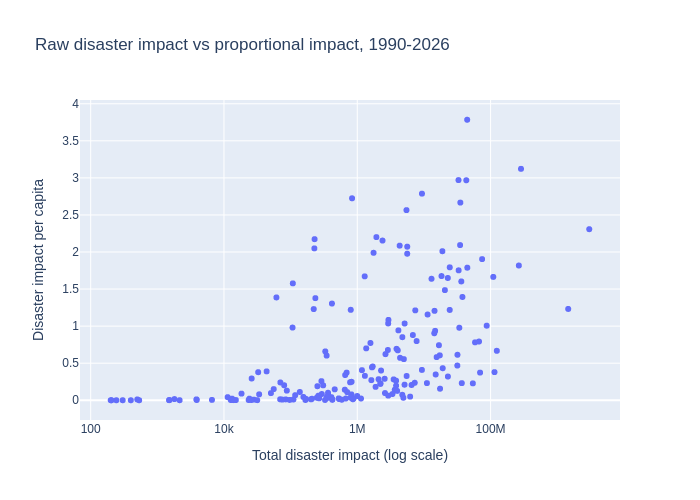

In [76]:
import plotly.express as px

# Use your full dataframe (not just top 10) to see the whole relationship
fig = px.scatter(
    df_dis_country_pop_avg,
    x='cumulative_disaster_impact',
    y='cumulative_affected_per_capita',
    hover_name='country_of_origin',
    log_x=True,  # log scale because country sizes range from tiny to billions
    title='Raw disaster impact vs proportional impact, 1990-2026',
    labels={
        'cumulative_disaster_impact': 'Total disaster impact (log scale)',
        'cumulative_affected_per_capita': 'Disaster impact per capita'
    }
)
fig.show()

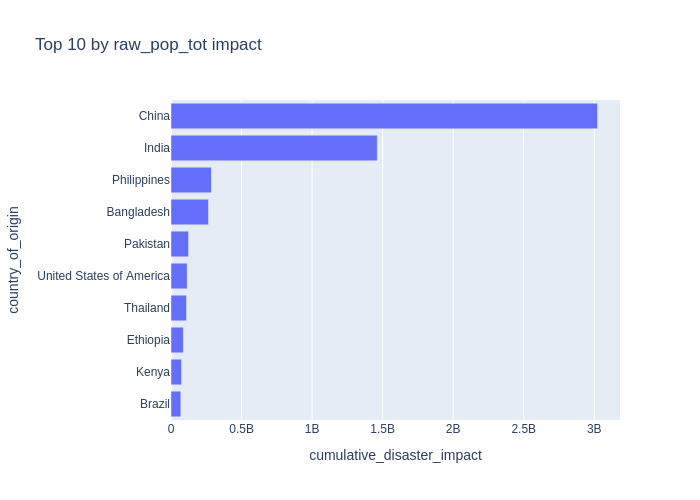

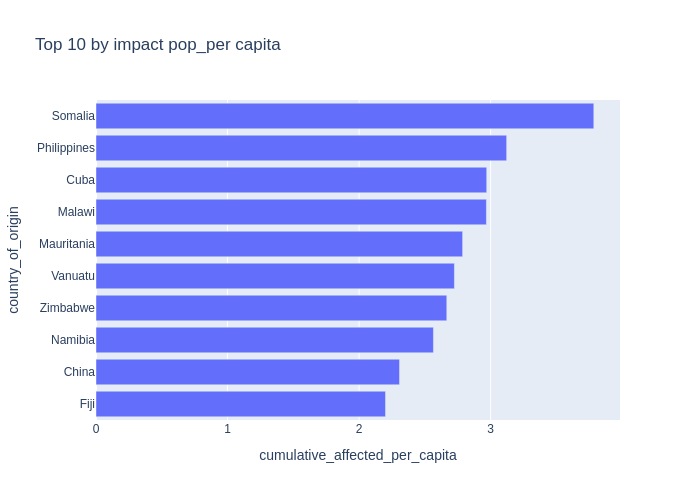

In [77]:
top10_raw = df_dis_country_pop_avg.sort_values('cumulative_disaster_impact', ascending=False).head(10)
top10_capita = df_dis_country_pop_avg.sort_values('cumulative_affected_per_capita', ascending=False).head(10)

fig1 = px.bar(top10_raw, x='cumulative_disaster_impact', y='country_of_origin', orientation='h', title='Top 10 by raw_pop_tot impact')
fig1.update_yaxes(categoryorder='total ascending')
fig1.show()

fig2 = px.bar(top10_capita, x='cumulative_affected_per_capita', y='country_of_origin', orientation='h', title='Top 10 by impact pop_per capita')
fig2.update_yaxes(categoryorder='total ascending')
fig2.show()

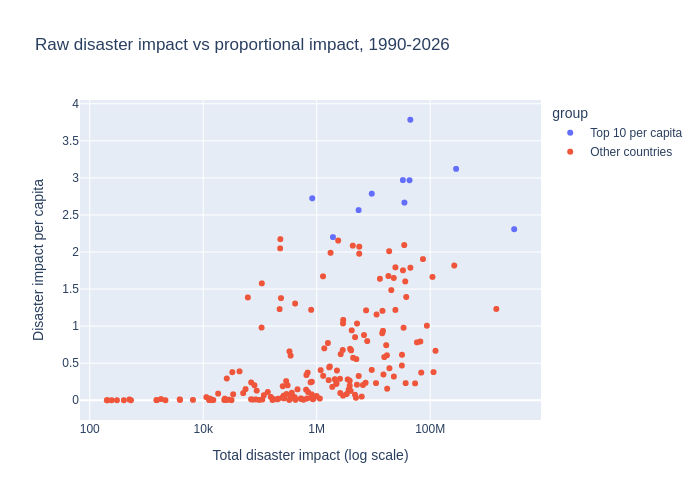

In [78]:
top10_iso = df_dis_country_pop_avg.sort_values('cumulative_affected_per_capita', ascending=False).head(10)['country_of_origin']

df_dis_country_pop_avg['group'] = df_dis_country_pop_avg['country_of_origin'].apply(
    lambda c: 'Top 10 per capita' if c in top10_iso.values else 'Other countries'
)

fig = px.scatter(
    df_dis_country_pop_avg,
    x='cumulative_disaster_impact',
    y='cumulative_affected_per_capita',
    color='group',
    hover_name='country_of_origin',
    log_x=True,
    title='Raw disaster impact vs proportional impact, 1990-2026',
    labels={
        'cumulative_disaster_impact': 'Total disaster impact (log scale)',
        'cumulative_affected_per_capita': 'Disaster impact per capita'
    }
)
fig.show()

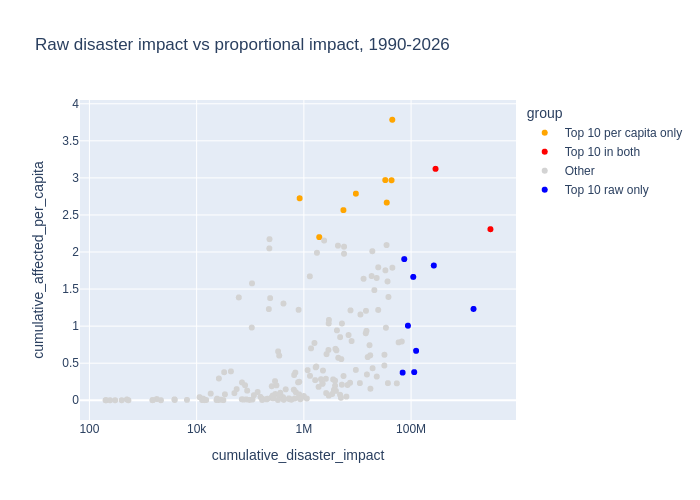

In [79]:
top10_raw_set = set(df_dis_country_pop_avg.sort_values('cumulative_disaster_impact', ascending=False).head(10)['country_of_origin'])
top10_capita_set = set(df_dis_country_pop_avg.sort_values('cumulative_affected_per_capita', ascending=False).head(10)['country_of_origin'])

def classify(country):
    in_raw = country in top10_raw_set
    in_capita = country in top10_capita_set
    if in_raw and in_capita:
        return 'Top 10 in both'
    elif in_raw:
        return 'Top 10 raw only'
    elif in_capita:
        return 'Top 10 per capita only'
    else:
        return 'Other'

df_dis_country_pop_avg['group'] = df_dis_country_pop_avg['country_of_origin'].apply(classify)

fig = px.scatter(
    df_dis_country_pop_avg,
    x='cumulative_disaster_impact',
    y='cumulative_affected_per_capita',
    color='group',
    hover_name='country_of_origin',
    log_x=True,
    title='Raw disaster impact vs proportional impact, 1990-2026',
    color_discrete_map={
        'Top 10 in both': 'red',
        'Top 10 raw only': 'blue',
        'Top 10 per capita only': 'orange',
        'Other': 'lightgrey'
    }
)
fig.show()

In [80]:
## break down ONLY those countries by disaster type- can always change within all countries if needed to explore but now ;  we look into countries show the strongest disaster-to-displacement link- based on population propotion NOT propotion size, breaking those specific countries down by disaster type tells you WHY, climate-related (flood, storm, drought) versus geophysical (earthquake) versus other

In [81]:
query= '''
SELECT
  country_of_origin,
  SUM(n_drought) AS drought,
  SUM(n_flood) AS flood,
  SUM(n_storm) AS storm,
  SUM(n_earthquake) AS earthquake,
  SUM(n_wildfire) AS wildfire,
  SUM(n_mass_movement) AS mass_movement,
  SUM(n_extreme_temp) AS extreme_temp,
  SUM(n_biological) AS biological
FROM `ontherun-499508.mart.mart_disaster_analysis`
WHERE country_of_origin IN ('Somalia', 'Philippines', 'Cuba', 'Malawi', 'Mauritania', 'Vanuatu', 'Zimbabwe', 'Namibia', 'China', 'Fiji')
GROUP BY country_of_origin
'''

df_top10_dis_cap = pd_gbq.read_gbq(query, project_id="ontherun-499508")

Downloading: 100%|██████████|


In [82]:
df_top10_dis_cap

,country_of_origin,drought,flood,storm,earthquake,wildfire,mass_movement,extreme_temp,biological
0,China,34,271,291,145,7,80,13,5
1,Mauritania,8,19,3,0,0,0,0,4
2,Namibia,9,18,0,0,0,0,0,6
3,Somalia,11,46,7,1,0,0,0,30
4,Zimbabwe,9,13,9,0,0,0,0,27
5,Philippines,6,137,265,34,1,27,1,18
6,Cuba,4,21,41,2,1,0,0,2
7,Fiji,2,7,24,0,0,0,0,1
8,Malawi,9,41,10,2,0,1,0,16
9,Vanuatu,0,0,5,1,0,0,0,0


In [83]:
# Combine both top 10 lists so you see disaster-type context for every flagged country
flagged_countries = top10_raw_set.union(top10_capita_set)

# Convert to a comma-separated string BigQuery can use in an IN clause
country_list_str = ", ".join(f"'{c}'" for c in flagged_countries)

query = f'''
SELECT
  country_of_origin,
  SUM(n_drought) AS drought,
  SUM(n_flood) AS flood,
  SUM(n_storm) AS storm,
  SUM(n_earthquake) AS earthquake,
  SUM(n_wildfire) AS wildfire,
  SUM(n_mass_movement) AS mass_movement,
  SUM(n_extreme_temp) AS extreme_temp,
  SUM(n_biological) AS biological
FROM `ontherun-499508.mart.mart_disaster_analysis`
WHERE country_of_origin IN ({country_list_str})
GROUP BY country_of_origin
'''

df_disaster_types = pd_gbq.read_gbq(query, project_id="ontherun-499508")
df_disaster_types

Downloading: 100%|██████████|


,country_of_origin,drought,flood,storm,earthquake,wildfire,mass_movement,extreme_temp,biological
0,Bangladesh,1,74,116,8,0,6,23,19
1,China,34,271,291,145,7,80,13,5
2,India,7,248,135,16,3,48,43,41
3,Pakistan,2,103,28,25,1,22,18,14
4,Ethiopia,12,53,1,2,1,10,0,26
5,Mauritania,8,19,3,0,0,0,0,4
6,Namibia,9,18,0,0,0,0,0,6
7,Somalia,11,46,7,1,0,0,0,30
8,Zimbabwe,9,13,9,0,0,0,0,27
9,Philippines,6,137,265,34,1,27,1,18


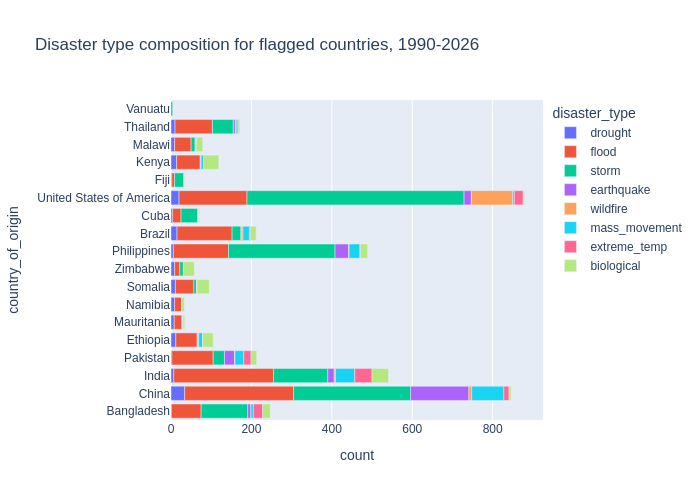

In [84]:
df_long = df_disaster_types.melt(
    id_vars='country_of_origin',
    var_name='disaster_type',
    value_name='count'
)

fig = px.bar(
    df_long,
    x='count',
    y='country_of_origin',
    color='disaster_type',
    orientation='h',
    title='Disaster type composition for flagged countries, 1990-2026'
)
fig.show()

Downloading: 100%|██████████|


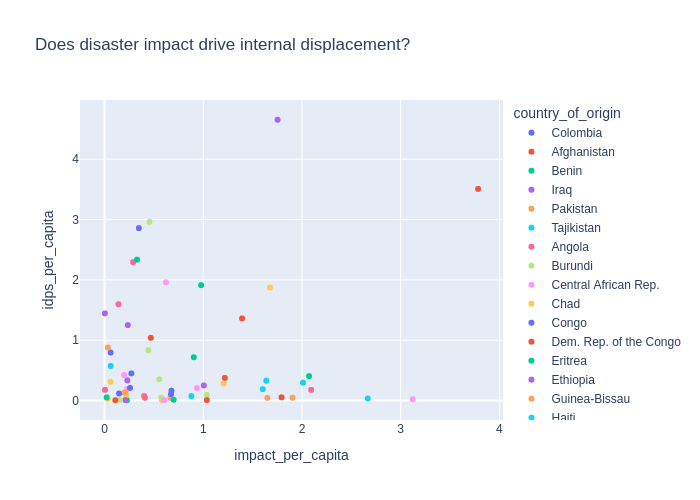

In [85]:
from google.cloud import bigquery
import pandas_gbq as pd_gbq

query = '''
SELECT
  country_of_origin,
  region,
  avg_population,
  impact_per_capita,
  SAFE_DIVIDE(total_idps, avg_population) AS idps_per_capita,
  SAFE_DIVIDE(total_refugees, avg_population) AS refugees_per_capita
FROM `ontherun-499508.mart.mart_dis_agg_pop`
WHERE avg_population > 0
  AND total_idps > 0
'''

df = pd_gbq.read_gbq(query, project_id='ontherun-499508')

import plotly.express as px
fig = px.scatter(
    df,
    x='impact_per_capita',
    y='idps_per_capita',
    hover_name='country_of_origin',
    color='country_of_origin',
    title='Does disaster impact drive internal displacement?'
)
fig.show()

In [86]:
print(df.shape)
print(df.head(20))

(63, 6)
         country_of_origin    region  avg_population  impact_per_capita  \
0                 Colombia  Americas   43,175,659.42               0.35   
1              Afghanistan      Asia   27,163,396.36               1.39   
2                    Benin    Africa    9,819,905.33               0.23   
3                     Iraq      Asia   30,871,750.14               0.24   
4                 Pakistan      Asia  186,004,481.17               0.67   
5               Tajikistan      Asia    7,754,401.91               0.88   
6                   Angola    Africa   22,804,456.86               0.41   
7                  Burundi    Africa    8,999,045.78               0.55   
8     Central African Rep.    Africa    4,260,646.67               0.62   
9                     Chad    Africa   11,951,350.67               1.21   
10                   Congo    Africa    4,242,218.40               0.68   
11  Dem. Rep. of the Congo    Africa   67,718,361.56               0.47   
12               

In [87]:
query = '''
SELECT
  country_of_origin,
  region,
  avg_population,
  impact_per_capita,
  total_idps,
  total_refugees,
  SAFE_DIVIDE(total_idps, avg_population) AS idps_per_capita,
  SAFE_DIVIDE(total_refugees, avg_population) AS refugees_per_capita
FROM `ontherun-499508.mart.mart_dis_agg_pop`
WHERE avg_population > 0
'''

df = pd_gbq.read_gbq(query, project_id='ontherun-499508')
df = df.dropna(subset=['impact_per_capita', 'idps_per_capita'])
print(f'Countries in dataframe: {df.shape[0]}')

Downloading: 100%|██████████|
Countries in dataframe: 188


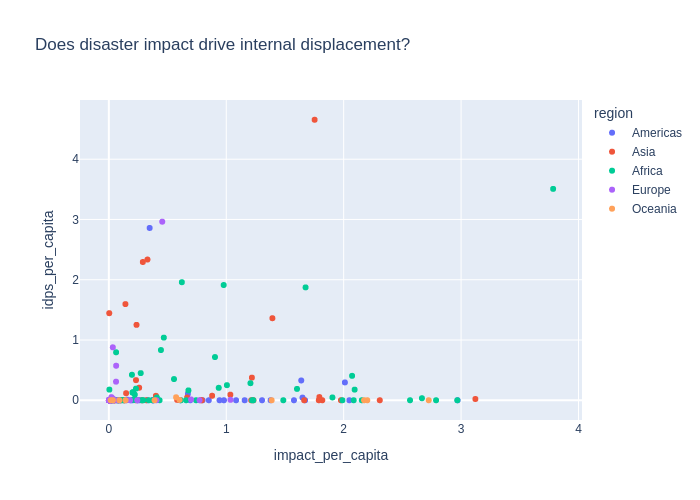

In [88]:
fig = px.scatter(
    df,
    x='impact_per_capita',
    y='idps_per_capita',
    hover_name='country_of_origin',
    color='region',
    title='Does disaster impact drive internal displacement?'
)
fig.show()